In [162]:
import pandas as pd
import numpy as np

In [163]:
data=pd.read_csv("poly.csv")
df=pd.DataFrame(data)
df

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [164]:
df=df.drop(columns=["sno"],axis=1)

In [165]:
df.dtypes

Temperature      int64
Pressure       float64
dtype: object

In [166]:
X=df.iloc[:,:-1]
Y=df.iloc[:,-1]

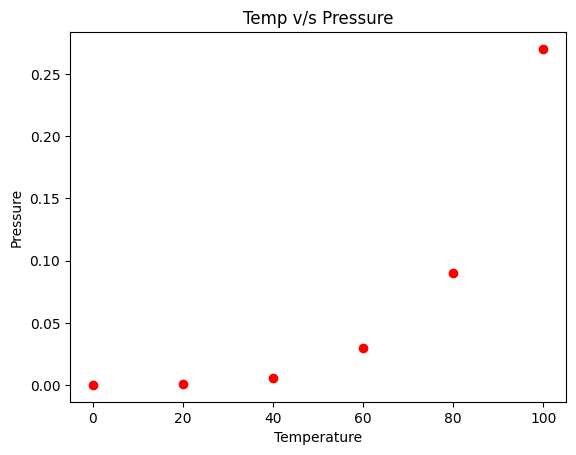

In [167]:
from matplotlib import pyplot

pyplot.scatter(X,Y,color="red")
pyplot.xlabel("Temperature")
pyplot.ylabel("Pressure")
pyplot.title("Temp v/s Pressure")
pyplot.show()

In [168]:
# from sklearn.model_selection import train_test_split

# X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)

In [169]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()

lr=lr.fit(X,Y)

Y_pred=lr.predict(X)

Y_pred

array([-0.05086667, -0.00402667,  0.04281333,  0.08965333,  0.13649333,
        0.18333333])

In [170]:
from sklearn.metrics import r2_score,mean_absolute_percentage_error


print(f"mean_absolute_percentage_error = {mean_absolute_percentage_error(Y,Y_pred)}")
print(f"R2_Score = {r2_score(Y,Y_pred)}")

mean_absolute_percentage_error = 44.775078189300416
R2_Score = 0.690349972603981


In [171]:
Y_pred

array([-0.05086667, -0.00402667,  0.04281333,  0.08965333,  0.13649333,
        0.18333333])

In [172]:
Y

0    0.0002
1    0.0012
2    0.0060
3    0.0300
4    0.0900
5    0.2700
Name: Pressure, dtype: float64

In [173]:
from sklearn.preprocessing import PolynomialFeatures

pf=PolynomialFeatures(degree=4)

X_poly=pf.fit_transform(X)

X_poly


array([[1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [1.000e+00, 2.000e+01, 4.000e+02, 8.000e+03, 1.600e+05],
       [1.000e+00, 4.000e+01, 1.600e+03, 6.400e+04, 2.560e+06],
       [1.000e+00, 6.000e+01, 3.600e+03, 2.160e+05, 1.296e+07],
       [1.000e+00, 8.000e+01, 6.400e+03, 5.120e+05, 4.096e+07],
       [1.000e+00, 1.000e+02, 1.000e+04, 1.000e+06, 1.000e+08]])

In [174]:
model_1=LinearRegression()

model=model_1.fit(X_poly,Y)  # X,y

Y_pred_2=model_1.predict(X_poly)


In [175]:
Y_pred_2

array([ 4.61111118e-04, -1.05555549e-04,  8.61111111e-03,  2.73888889e-02,
        9.13055556e-02,  2.69738889e-01])

In [176]:
df_1=pd.DataFrame({"Actual_Values":Y,"Simple_linear_Values":Y_pred,"Polynomial_Values":Y_pred_2})
df_1

,Actual_Values,Simple_linear_Values,Polynomial_Values
0,0.0002,-0.050867,0.000461
1,0.0012,-0.004027,-0.000106
2,0.0060,0.042813,0.008611
3,0.0300,0.089653,0.027389
4,0.0900,0.136493,0.091306
5,0.2700,0.183333,0.269739


In [177]:
print(mean_absolute_percentage_error(Y,Y_pred_2))
print(r2_score(Y,Y_pred_2))

0.48853566978640667
0.9996910780718014
